In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
import xgboost

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last"

In [4]:
data = pd.read_csv("data/train_users_2.csv")
sessions = pd.read_csv("data/sessions.csv")

In [5]:
display(data.shape, sessions.shape)

display(data.head(5))
display(sessions.head(5))


(213451, 16)

(10567737, 6)

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0
3,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,22141.0
4,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,435.0


Total unique Actions: 359
Total unique Device Types: 14

--- Action Statistics (Top 10) ---
action
show                     2768278
index                     843699
search_results            725226
personalize               706824
search                    536057
ajax_refresh_subtotal     487744
update                    365130
similar_listings          364624
social_connections        339000
reviews                   320591
Name: count, dtype: int64

--- Device Type Statistics ---
device_type
Mac Desktop                         3594286
Windows Desktop                     2658539
iPhone                              2105031
Android Phone                        839637
iPad Tablet                          683414
Android App Unknown Phone/Tablet     273652
-unknown-                            211279
Tablet                               139886
Linux Desktop                         28373
Chromebook                            22348
iPodtouch                              8198
Windows Phone    

C:\Users\ralma\AppData\Local\Temp\ipykernel_25280\2597527722.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=action_stats.head(20).index, y=action_stats.head(20).values, palette='viridis')
C:\Users\ralma\AppData\Local\Temp\ipykernel_25280\2597527722.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_stats.index, y=device_stats.values, palette='magma')


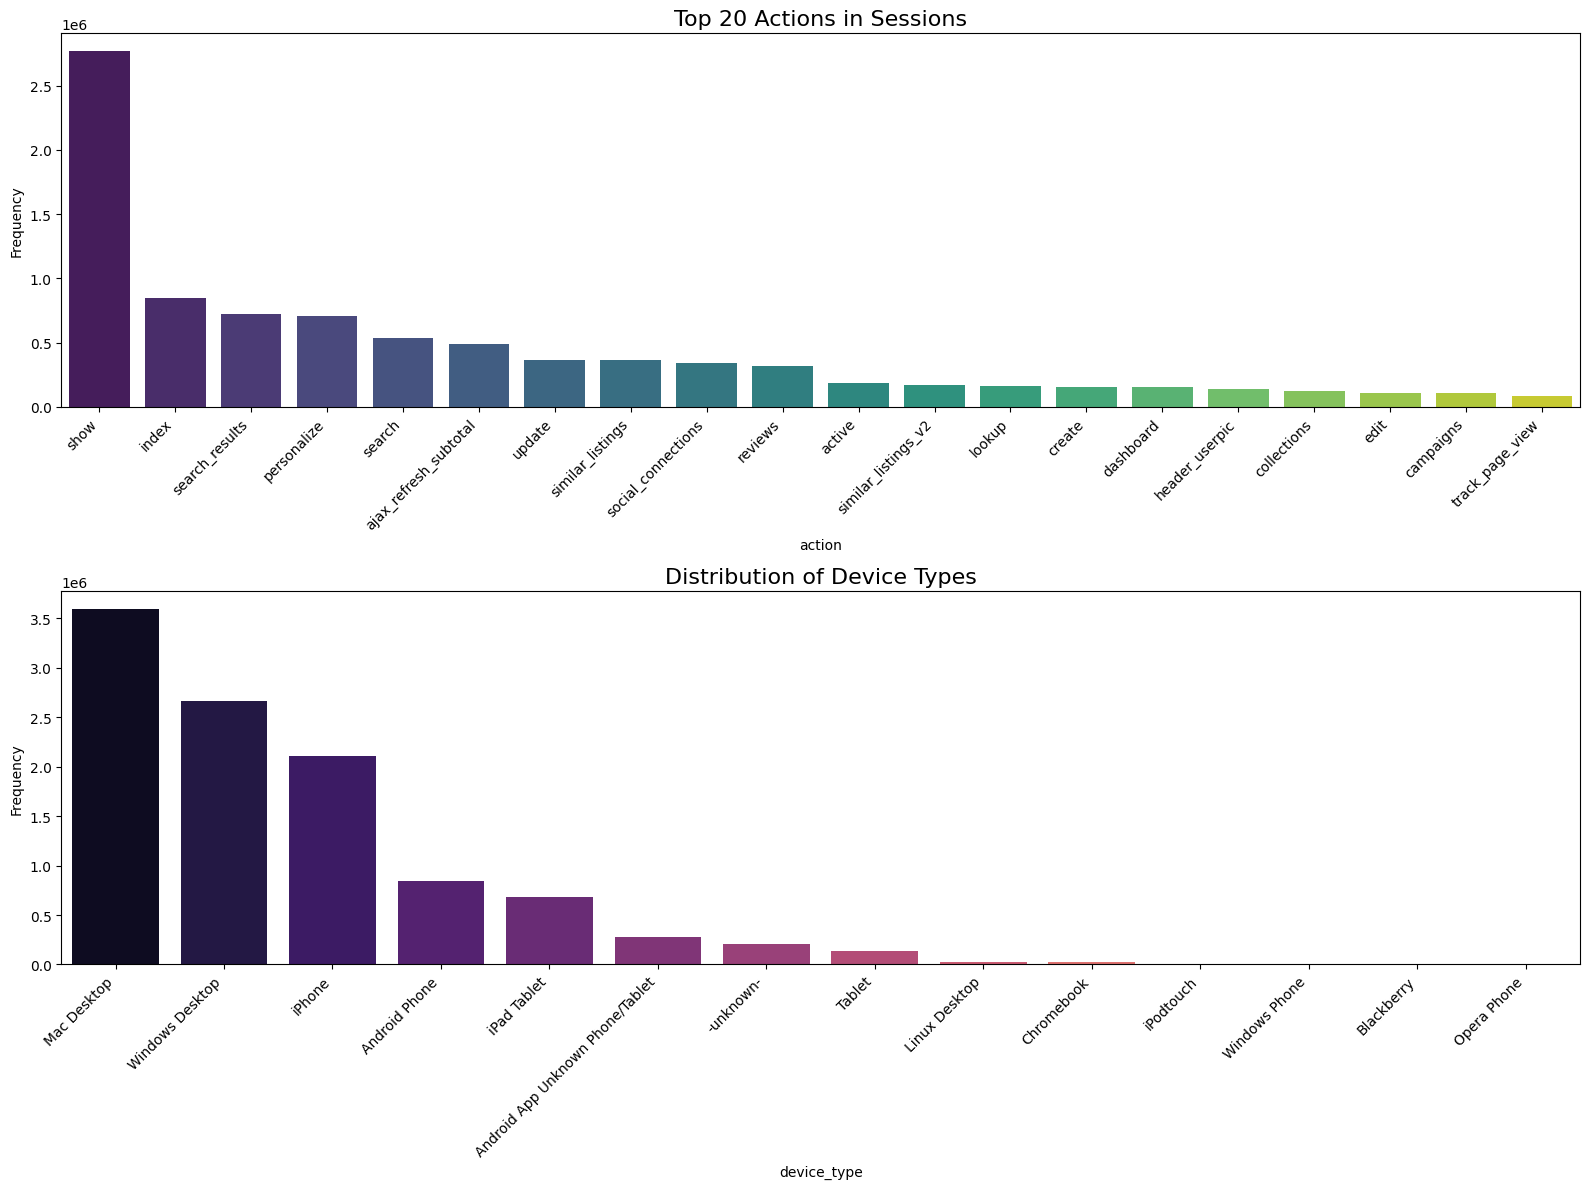

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'sessions' is already loaded as a DataFrame
# If not, use: sessions = pd.read_csv('sessions.csv')

# 1. Check for the number of unique keywords (unique values)
num_actions = sessions['action'].nunique()
num_devices = sessions['device_type'].nunique()

print(f"Total unique Actions: {num_actions}")
print(f"Total unique Device Types: {num_devices}")

# 2. Get Statistics (Frequency Counts)
action_stats = sessions['action'].value_counts()
device_stats = sessions['device_type'].value_counts()

print("\n--- Action Statistics (Top 10) ---")
print(action_stats.head(10))

print("\n--- Device Type Statistics ---")
print(device_stats)

# 3. Plotting the Charts
plt.figure(figsize=(16, 12))

# Subplot 1: Top 20 Actions
plt.subplot(2, 1, 1)
sns.barplot(x=action_stats.head(20).index, y=action_stats.head(20).values, palette='viridis')
plt.title('Top 20 Actions in Sessions', fontsize=16)
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

# Subplot 2: Device Type Distribution
plt.subplot(2, 1, 2)
sns.barplot(x=device_stats.index, y=device_stats.values, palette='magma')
plt.title('Distribution of Device Types', fontsize=16)
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('sessions_analysis.png')
plt.show()

In [7]:
print("data columns:", data.columns.tolist())
print("\nSESSIONS columns:", sessions.columns.tolist())

display(data.dtypes.to_frame("dtype"))
display(sessions.dtypes.to_frame("dtype"))

data columns: ['id', 'date_account_created', 'timestamp_first_active', 'date_first_booking', 'gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'country_destination']

SESSIONS columns: ['user_id', 'action', 'action_type', 'action_detail', 'device_type', 'secs_elapsed']


,dtype
id,object
date_account_created,object
timestamp_first_active,int64
date_first_booking,object
gender,object
age,float64
signup_method,object
signup_flow,int64
language,object
affiliate_channel,object


,dtype
user_id,object
action,object
action_type,object
action_detail,object
device_type,object
secs_elapsed,float64


In [8]:
def missing_report(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\n{name} - Missing columns: {len(miss)} / {df.shape[1]}")
    if len(miss):
        display(pd.DataFrame({
            "missing": miss,
            "missing_%": (miss / len(df) * 100).round(2)
        }))

missing_report(data, "data")
missing_report(sessions, "sessions")


data - Missing columns: 3 / 16


,missing,missing_%
date_first_booking,124543,58.35
age,87990,41.22
first_affiliate_tracked,6065,2.84



sessions - Missing columns: 5 / 6


,missing,missing_%
action_type,1126204,10.66
action_detail,1126204,10.66
secs_elapsed,136031,1.29
action,79626,0.75
user_id,34496,0.33


In [9]:
display(data.describe(include=[np.number]).T)
display(sessions.describe(include=[np.number]).T)

,count,mean,std,min,25%,50%,75%,max
timestamp_first_active,213451.0,2.013085e+13,9.253717e+09,2.009032e+13,2.012123e+13,2.013091e+13,2.014031e+13,2.014063e+13
age,125461.0,4.966834e+01,1.556666e+02,1.000000e+00,2.800000e+01,3.400000e+01,4.300000e+01,2.014000e+03
signup_flow,213451.0,3.267387e+00,7.637707e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e+01


,count,mean,std,min,25%,50%,75%,max
secs_elapsed,10431706.0,19405.810751,88884.243209,0.0,229.0,1147.0,8444.0,1799977.0


In [10]:
if "id" in data.columns:
    print("data.id unique:", data["id"].nunique(), " / rows:", len(data))
if "user_id" in sessions.columns:
    print("sessions.user_id unique:", sessions["user_id"].nunique(), " / rows:", len(sessions))

# how many data users have sessions?
if "id" in data.columns and "user_id" in sessions.columns:
    overlap = sessions["user_id"].isin(data["id"]).mean()
    print("Share of sessions rows whose user_id exists in data.id:", round(overlap, 4))

data.id unique: 213451  / rows: 213451
sessions.user_id unique: 135483  / rows: 10567737
Share of sessions rows whose user_id exists in data.id: 0.524


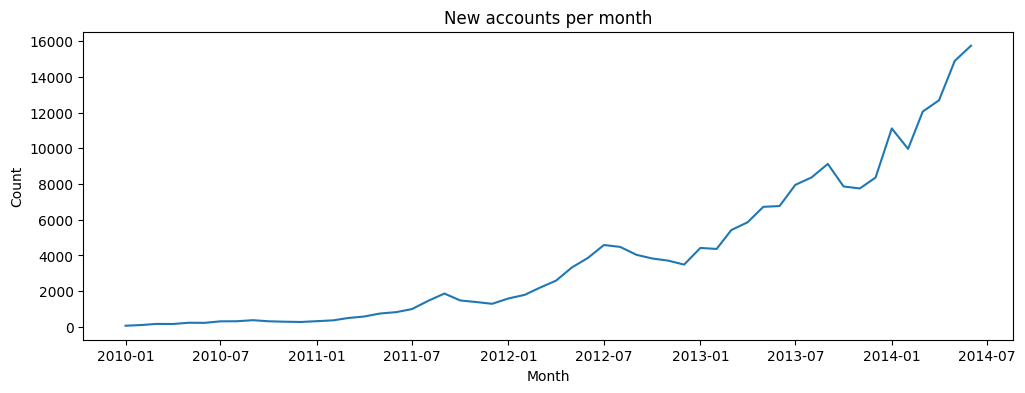

In [11]:
import matplotlib.pyplot as plt

# If you already dropped date_account_created, reload just that column
dac = pd.read_csv("data/train_users_2.csv", usecols=["date_account_created"])
dac["date_account_created"] = pd.to_datetime(dac["date_account_created"], errors="coerce")

# Monthly trend
monthly = dac.set_index("date_account_created").resample("MS").size()
plt.figure(figsize=(12,4))
plt.plot(monthly.index, monthly.values)
plt.title("New accounts per month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


In [12]:
dac = pd.read_csv("data/train_users_2.csv", usecols=["date_account_created"])
dac["date_account_created"] = pd.to_datetime(dac["date_account_created"], errors="coerce")

print("Min date:", dac["date_account_created"].min())
print("Max date:", dac["date_account_created"].max())


Min date: 2010-01-01 00:00:00
Max date: 2014-06-30 00:00:00


In [13]:
# =========================
# 1) Convert date columns properly
# =========================

data["date_account_created"] = pd.to_datetime(data["date_account_created"])
data["date_first_booking"] = pd.to_datetime(data["date_first_booking"], errors="coerce")

# timestamp_first_active conversion
data["timestamp_first_active"] = pd.to_datetime(
    data["timestamp_first_active"].astype(str),
    format="%Y%m%d%H%M%S"
)

print("Date conversion done.")


Date conversion done.


In [14]:
# =========================
# 2) Fix age column professionally
# =========================

# Replace impossible ages
data.loc[data["age"] < 15, "age"] = np.nan
data.loc[data["age"] > 90, "age"] = np.nan

# Also handle birth year case (1900-2014 range)
data.loc[(data["age"] > 1900) & (data["age"] < 2015), "age"] = \
    2015 - data.loc[(data["age"] > 1900) & (data["age"] < 2015), "age"]

print("Age cleaned.")


Age cleaned.


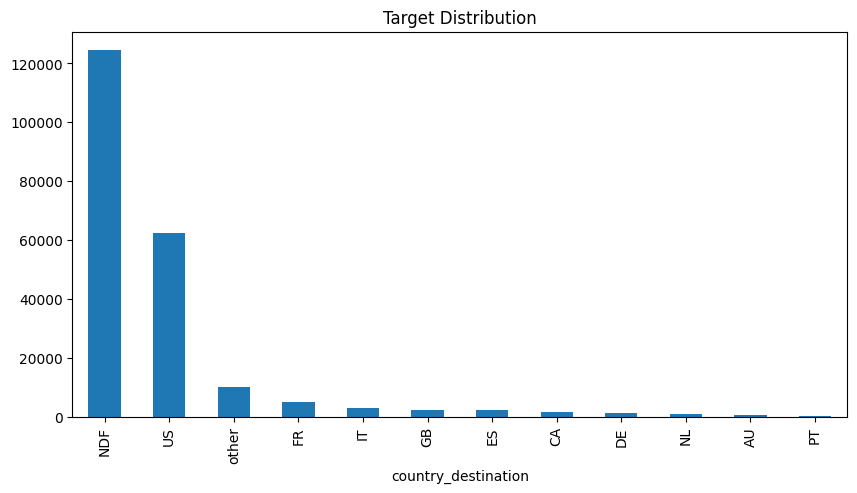

country_destination
NDF      0.583473
US       0.292226
other    0.047290
FR       0.023532
IT       0.013282
GB       0.010888
ES       0.010536
CA       0.006690
DE       0.004971
NL       0.003570
AU       0.002525
PT       0.001017
Name: proportion, dtype: float64

In [15]:
# =========================
# 4) Target Distribution (VERY IMPORTANT)
# =========================

plt.figure(figsize=(10,5))
data["country_destination"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

data["country_destination"].value_counts(normalize=True)


In [16]:
data.age.describe()

count    122861.000000
mean         36.463809
std          11.455232
min          15.000000
25%          28.000000
50%          33.000000
75%          42.000000
max          90.000000
Name: age, dtype: float64

In [17]:
target_counts = data["country_destination"].value_counts()
print(target_counts)
print(target_counts / len(data))


country_destination
NDF      124543
US        62376
other     10094
FR         5023
IT         2835
GB         2324
ES         2249
CA         1428
DE         1061
NL          762
AU          539
PT          217
Name: count, dtype: int64
country_destination
NDF      0.583473
US       0.292226
other    0.047290
FR       0.023532
IT       0.013282
GB       0.010888
ES       0.010536
CA       0.006690
DE       0.004971
NL       0.003570
AU       0.002525
PT       0.001017
Name: count, dtype: float64


In [18]:
data = data.drop(columns=["date_first_booking"])
# That column contains future information.

In [19]:
data["gender"] = data["gender"].replace("-unknown-", np.nan)


In [20]:
data["age_missing"] = data["age"].isna().astype(int)

In [21]:
print(data["first_affiliate_tracked"].isna().mean())


0.028414015394633896


In [22]:
data["first_affiliate_tracked"] = data["first_affiliate_tracked"].fillna("unknown")


In [23]:
data["date_account_created"] = pd.to_datetime(data["date_account_created"], errors="coerce")

data["timestamp_first_active"] = pd.to_datetime(
    data["timestamp_first_active"].astype(str).str.strip(),
    errors="coerce",
    format="mixed"
)


In [24]:
print("DAC NaT %:", data["date_account_created"].isna().mean())
print("TFA NaT %:", data["timestamp_first_active"].isna().mean())

data[["date_account_created","timestamp_first_active"]].head()
data[["date_account_created","timestamp_first_active"]].dtypes

DAC NaT %: 0.0
TFA NaT %: 0.0


date_account_created      datetime64[ns]
timestamp_first_active    datetime64[ns]
dtype: object

In [25]:
data["dac_year"] = data["date_account_created"].dt.year
data["dac_month"] = data["date_account_created"].dt.month
data["dac_day"] = data["date_account_created"].dt.day
data["dac_weekday"] = data["date_account_created"].dt.weekday

data["tfa_year"] = data["timestamp_first_active"].dt.year
data["tfa_month"] = data["timestamp_first_active"].dt.month
data["tfa_day"] = data["timestamp_first_active"].dt.day
data["tfa_hour"] = data["timestamp_first_active"].dt.hour


In [26]:
data["days_from_active_to_create"] = (
    data["date_account_created"] - data["timestamp_first_active"]
).dt.days


In [27]:
data = data.drop(columns=[
    "date_account_created",
    "timestamp_first_active"
])


In [28]:
print("Duplicate IDs:", data["id"].duplicated().sum())


Duplicate IDs: 0


In [29]:
cat_cols = [
    "gender", "signup_method", "language",
    "affiliate_channel", "affiliate_provider",
    "first_affiliate_tracked", "signup_app",
    "first_device_type", "first_browser"
]

for col in cat_cols:
    data[col] = data[col].astype("str")


In [30]:
data.info()
data.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          213451 non-null  object 
 1   gender                      213451 non-null  object 
 2   age                         122861 non-null  float64
 3   signup_method               213451 non-null  object 
 4   signup_flow                 213451 non-null  int64  
 5   language                    213451 non-null  object 
 6   affiliate_channel           213451 non-null  object 
 7   affiliate_provider          213451 non-null  object 
 8   first_affiliate_tracked     213451 non-null  object 
 9   signup_app                  213451 non-null  object 
 10  first_device_type           213451 non-null  object 
 11  first_browser               213451 non-null  object 
 12  country_destination         213451 non-null  object 
 13  age_missing   

,count,mean,std,min,25%,50%,75%,max
age,122861.0,36.463809,11.455232,15.0,28.0,33.0,42.0,90.0
signup_flow,213451.0,3.267387,7.637707,0.0,0.0,0.0,0.0,25.0
age_missing,213451.0,0.424407,0.494254,0.0,0.0,0.0,1.0,1.0
dac_year,213451.0,2013.023846,0.938489,2010.0,2012.0,2013.0,2014.0,2014.0
dac_month,213451.0,6.022459,3.236690,1.0,3.0,6.0,9.0,12.0
dac_day,213451.0,15.869230,8.740107,1.0,8.0,16.0,23.0,31.0
dac_weekday,213451.0,2.764246,1.944807,0.0,1.0,3.0,4.0,6.0
tfa_year,213451.0,2013.023218,0.939039,2009.0,2012.0,2013.0,2014.0,2014.0
tfa_month,213451.0,6.022385,3.236501,1.0,3.0,6.0,9.0,12.0
tfa_day,213451.0,15.869071,8.739582,1.0,8.0,16.0,23.0,31.0


In [31]:
data["age"] = data["age"].fillna(data["age"].median())


In [32]:
# Fill missing categorical fields
sessions["action"] = sessions["action"].fillna("unknown")
sessions["action_type"] = sessions["action_type"].fillna("unknown")
sessions["action_detail"] = sessions["action_detail"].fillna("unknown")
sessions["device_type"] = sessions["device_type"].fillna("unknown")

# Fill missing time with 0
sessions["secs_elapsed"] = sessions["secs_elapsed"].fillna(0)


In [33]:
# Total number of session rows per user
sess_agg = sessions.groupby("user_id").agg(
    total_actions=("action", "count"),
    total_secs=("secs_elapsed", "sum"),
    mean_secs=("secs_elapsed", "mean"),
    std_secs=("secs_elapsed", "std"),
    unique_actions=("action", "nunique"),
    unique_action_types=("action_type", "nunique"),
    unique_devices=("device_type", "nunique"),
)

# Replace NaN std with 0
sess_agg["std_secs"] = sess_agg["std_secs"].fillna(0)

sess_agg.head()


,total_actions,total_secs,mean_secs,std_secs,unique_actions,unique_action_types,unique_devices
user_id,,,,,,,
00023iyk9l,40,867896.0,21697.400000,91120.246977,14,7,2
0010k6l0om,63,586543.0,9310.206349,22598.457942,11,6,1
001wyh0pz8,90,282965.0,3144.055556,6541.226692,10,6,1
0028jgx1x1,31,297010.0,9580.967742,17791.419521,5,5,2
002qnbzfs5,789,6487080.0,8221.901141,58074.501758,26,8,2


In [34]:
data = data.merge(
    sess_agg,
    left_on="id",
    right_index=True,
    how="left"
)


In [35]:
session_cols = [
    "total_actions", "total_secs", "mean_secs",
    "std_secs", "unique_actions",
    "unique_action_types", "unique_devices"
]

data[session_cols] = data[session_cols].fillna(0)


In [36]:
display(data.shape)
display(data.head(5))
display(data[session_cols].describe().T)
display("name of columns:", data.columns.tolist())



(213451, 30)

,id,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,...,tfa_day,tfa_hour,days_from_active_to_create,total_actions,total_secs,mean_secs,std_secs,unique_actions,unique_action_types,unique_devices
0,gxn3p5htnn,nan,33.0,facebook,0,en,direct,direct,untracked,Web,...,19,4,465,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,820tgsjxq7,MALE,38.0,facebook,0,en,seo,google,untracked,Web,...,23,17,731,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4ft3gnwmtx,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,...,9,23,475,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,bjjt8pjhuk,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,...,31,6,764,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,87mebub9p4,nan,41.0,basic,0,en,direct,direct,untracked,Web,...,8,6,279,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
total_actions,213451.0,25.944863,7.518941e+01,0.0,0.0,0.0,15.000000,2.644000e+03
total_secs,213451.0,523648.301006,1.335854e+06,0.0,0.0,0.0,306046.500000,3.822136e+07
mean_secs,213451.0,10020.958908,2.926706e+04,0.0,0.0,0.0,9632.758255,9.313587e+05
std_secs,213451.0,27266.212705,6.642494e+04,0.0,0.0,0.0,21716.476672,1.204374e+06
unique_actions,213451.0,4.468890,7.802415e+00,0.0,0.0,0.0,8.000000,7.200000e+01
unique_action_types,213451.0,1.939026,2.852514e+00,0.0,0.0,0.0,5.000000,9.000000e+00
unique_devices,213451.0,0.454287,7.057529e-01,0.0,0.0,0.0,1.000000,6.000000e+00


'name of columns:'

['id',
 'gender',
 'age',
 'signup_method',
 'signup_flow',
 'language',
 'affiliate_channel',
 'affiliate_provider',
 'first_affiliate_tracked',
 'signup_app',
 'first_device_type',
 'first_browser',
 'country_destination',
 'age_missing',
 'dac_year',
 'dac_month',
 'dac_day',
 'dac_weekday',
 'tfa_year',
 'tfa_month',
 'tfa_day',
 'tfa_hour',
 'days_from_active_to_create',
 'total_actions',
 'total_secs',
 'mean_secs',
 'std_secs',
 'unique_actions',
 'unique_action_types',
 'unique_devices']

# 📊 Dataset Feature Dictionary

This comprehensive list represents the final feature set used for predicting user travel destinations. It combines raw demographic data, engineered temporal features, and aggregated behavioral signals.

---

### 🆔 1. User Identification & Target
* **`id`**: Unique identifier for each user.
* **`country_destination`**: **(Target Variable)** The destination of the user's first booking (e.g., NDF, US, FR, etc.).

### 👤 2. Demographic Information
* **`gender`**: Self-declared gender (MALE, FEMALE, OTHER, unknown).
* **`age`**: User age (cleaned and imputed with median).
* **`age_missing`**: Binary indicator (`1` = originally missing, `0` = present).
* **`language`**: User’s preferred language.

### 🖱️ 3. Signup & Acquisition Details
* **`signup_method`**: Method used to sign up (basic, facebook, google, etc.).
* **`signup_flow`**: Numeric code representing the signup process page/flow.
* **`affiliate_channel`**: Marketing channel (direct, seo, ads, etc.).
* **`affiliate_provider`**: Specific marketing provider (google, facebook, etc.).
* **`first_affiliate_tracked`**: The first marketing affiliate the user interacted with.
* **`signup_app`**: Platform used to sign up (Web, iOS, Android).
* **`first_device_type`**: Initial device used to access the platform.
* **`first_browser`**: Initial browser used.

### 📅 4. Engineered Temporal Features
Derived from Account Creation (DAC) and Timestamp of First Activity (TFA):
* **`dac_year`, `dac_month`, `dac_day`, `dac_weekday`**: Time components of account creation.
* **`tfa_year`, `tfa_month`, `tfa_day`, `tfa_hour`**: Time components of the user's first activity.
* **`days_from_active_to_create`**: Day difference between first activity and account creation.

### 📈 5. Aggregated Session Behavior
*These features are generated by grouping the `sessions` dataset by user ID.*

| Feature | Description |
| :--- | :--- |
| **`total_actions`** | Total count of session records for the user. |
| **`total_secs`** | Total time (seconds) spent across all recorded sessions. |
| **`mean_secs`** | Average time spent per session action. |
| **`std_secs`** | Standard deviation of session duration (behavior variability). |
| **`unique_actions`** | Count of distinct actions performed. |
| **`unique_action_types`** | Count of distinct types of actions (click, view, etc.). |
| **`unique_devices`** | Number of unique devices used during sessions. |

---

In [37]:
log_cols = [
    "total_actions",
    "total_secs",
    "mean_secs",
    "std_secs"
]

for col in log_cols:
    data[f"log_{col}"] = np.log1p(data[col])


Log Transformation of Skewed Session Features

We applied a log transformation (np.log1p) to highly skewed behavioral features:

total_actions

total_secs

mean_secs

These variables have heavy right-tailed distributions (a small number of users have extremely large values). Such skewness can make models overly sensitive to outliers.

Users with NO session records: 139636
Users WITH session records: 73815


,count,pct_%
country_destination,,
NDF,79502,56.94
US,42281,30.28
other,6439,4.61
FR,3588,2.57
IT,1856,1.33
GB,1593,1.14
ES,1542,1.10
CA,988,0.71
DE,811,0.58


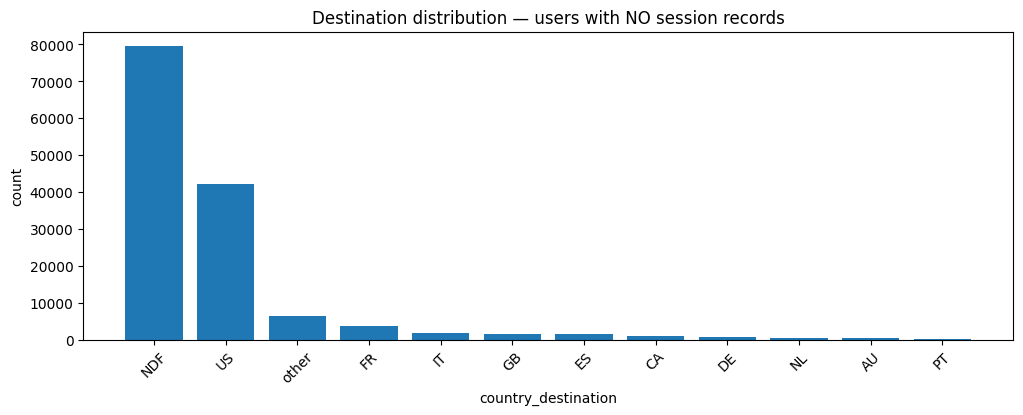

,count,pct_%
country_destination,,
NDF,45041,61.02
US,20095,27.22
other,3655,4.95
FR,1435,1.94
IT,979,1.33
GB,731,0.99
ES,707,0.96
CA,440,0.60
DE,250,0.34


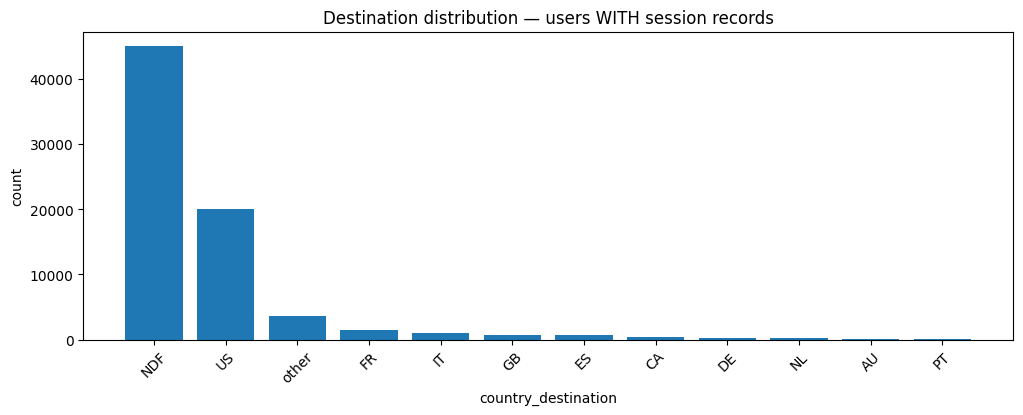

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) Define the two groups
no_sess = data[data["total_actions"] == 0]
has_sess = data[data["total_actions"] > 0]

print("Users with NO session records:", no_sess.shape[0])
print("Users WITH session records:", has_sess.shape[0])

# Common order for destinations (overall order by frequency)
dest_order = data["country_destination"].value_counts().index.tolist()

def plot_dest_distribution(df, title, order):
    counts = df["country_destination"].value_counts().reindex(order).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(2)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(counts.index, counts.values)
    ax.set_title(title)
    ax.set_xlabel("country_destination")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)

    # Print a small table for reference (top 12 destinations)
    display(pd.DataFrame({"count": counts, "pct_%": pct}).head(12))

    plt.show()

# 2) Plot counts (and show top table) for each group
plot_dest_distribution(no_sess, "Destination distribution — users with NO session records", dest_order)
plot_dest_distribution(has_sess, "Destination distribution — users WITH session records", dest_order)


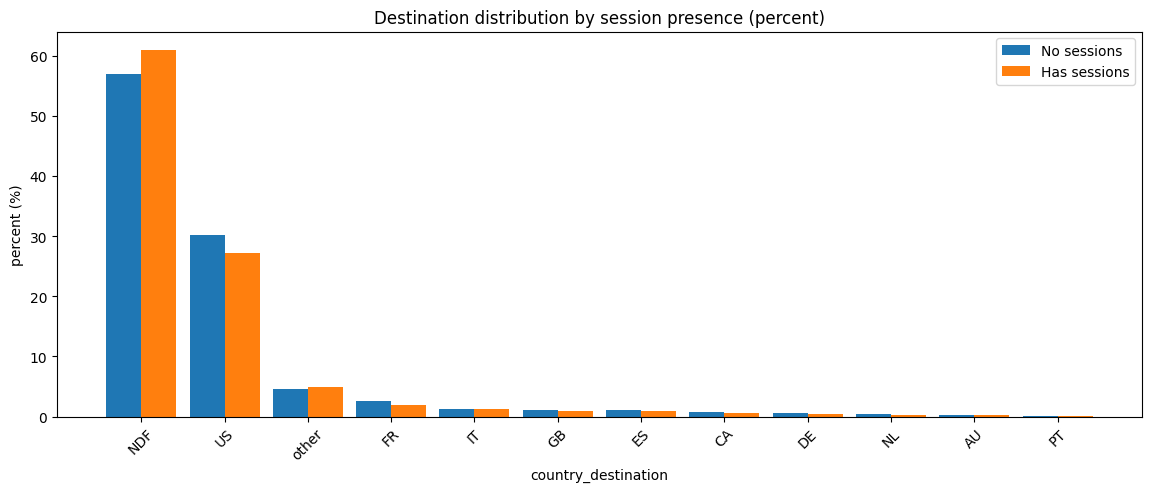

In [39]:
import numpy as np

no_counts = no_sess["country_destination"].value_counts().reindex(dest_order).fillna(0)
has_counts = has_sess["country_destination"].value_counts().reindex(dest_order).fillna(0)

no_pct = no_counts / no_counts.sum() * 100
has_pct = has_counts / has_counts.sum() * 100

x = np.arange(len(dest_order))
width = 0.42

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, no_pct.values, width, label="No sessions")
ax.bar(x + width/2, has_pct.values, width, label="Has sessions")

ax.set_title("Destination distribution by session presence (percent)")
ax.set_xlabel("country_destination")
ax.set_ylabel("percent (%)")
ax.set_xticks(x)
ax.set_xticklabels(dest_order, rotation=45)
ax.legend()
plt.show()


In [40]:
moreData = data.copy()
print(moreData.shape)


(213451, 34)


In [41]:
# List of devices used per user
device_list = sessions.groupby("user_id")["device_type"].unique()

# Most frequent device
top_device = (
    sessions.groupby(["user_id", "device_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["user_id", "count"], ascending=[True, False])
    .drop_duplicates("user_id")
    .set_index("user_id")["device_type"]
)

moreData = moreData.merge(device_list.rename("device_list"),
                          left_on="id", right_index=True, how="left")

moreData = moreData.merge(top_device.rename("top_device"),
                          left_on="id", right_index=True, how="left")

moreData["device_list"] = moreData["device_list"].apply(lambda x: list(x) if isinstance(x, np.ndarray) else [])
moreData["top_device"] = moreData["top_device"].fillna("none")


In [42]:
action_list = sessions.groupby("user_id")["action"].unique()

top_action = (
    sessions.groupby(["user_id", "action"])
    .size()
    .reset_index(name="count")
    .sort_values(["user_id", "count"], ascending=[True, False])
    .drop_duplicates("user_id")
    .set_index("user_id")["action"]
)

moreData = moreData.merge(action_list.rename("action_list"),
                          left_on="id", right_index=True, how="left")

moreData = moreData.merge(top_action.rename("top_action"),
                          left_on="id", right_index=True, how="left")

moreData["action_list"] = moreData["action_list"].apply(lambda x: list(x) if isinstance(x, np.ndarray) else [])
moreData["top_action"] = moreData["top_action"].fillna("none")


In [43]:
booking_keywords = ["book", "reserve", "confirm", "payment"]

sessions["is_booking_related"] = sessions["action"].str.contains(
    "|".join(booking_keywords), case=False, na=False
)

booking_counts = sessions.groupby("user_id")["is_booking_related"].sum()

moreData = moreData.merge(
    booking_counts.rename("booking_action_count"),
    left_on="id",
    right_index=True,
    how="left"
)

moreData["booking_action_count"] = moreData["booking_action_count"].fillna(0)


In [44]:
moreData["action_diversity_ratio"] = (
    moreData["unique_action_types"] /
    (moreData["total_actions"] + 1)
)


In [45]:
display(moreData.shape)
display(moreData.head())
display(moreData.columns.tolist())


(213451, 40)

,id,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,...,log_total_actions,log_total_secs,log_mean_secs,log_std_secs,device_list,top_device,action_list,top_action,booking_action_count,action_diversity_ratio
0,gxn3p5htnn,nan,33.0,facebook,0,en,direct,direct,untracked,Web,...,0.0,0.0,0.0,0.0,[],none,[],none,0.0,0.0
1,820tgsjxq7,MALE,38.0,facebook,0,en,seo,google,untracked,Web,...,0.0,0.0,0.0,0.0,[],none,[],none,0.0,0.0
2,4ft3gnwmtx,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,...,0.0,0.0,0.0,0.0,[],none,[],none,0.0,0.0
3,bjjt8pjhuk,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,...,0.0,0.0,0.0,0.0,[],none,[],none,0.0,0.0
4,87mebub9p4,nan,41.0,basic,0,en,direct,direct,untracked,Web,...,0.0,0.0,0.0,0.0,[],none,[],none,0.0,0.0


['id',
 'gender',
 'age',
 'signup_method',
 'signup_flow',
 'language',
 'affiliate_channel',
 'affiliate_provider',
 'first_affiliate_tracked',
 'signup_app',
 'first_device_type',
 'first_browser',
 'country_destination',
 'age_missing',
 'dac_year',
 'dac_month',
 'dac_day',
 'dac_weekday',
 'tfa_year',
 'tfa_month',
 'tfa_day',
 'tfa_hour',
 'days_from_active_to_create',
 'total_actions',
 'total_secs',
 'mean_secs',
 'std_secs',
 'unique_actions',
 'unique_action_types',
 'unique_devices',
 'log_total_actions',
 'log_total_secs',
 'log_mean_secs',
 'log_std_secs',
 'device_list',
 'top_device',
 'action_list',
 'top_action',
 'booking_action_count',
 'action_diversity_ratio']

log_total_actions

log_total_secs

log_mean_secs

log_std_secs

device_list

top_device

action_list

top_action

booking_action_count

action_diversity_ratio

In [52]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# =========================
# Choose dataset here:
# =========================
DATASET_TO_USE = "moreData"  # "data" or "moreData"

if DATASET_TO_USE == "data":
    dataset = data
elif DATASET_TO_USE == "moreData":
    dataset = moreData
else:
    raise ValueError("DATASET_TO_USE must be 'data' or 'moreData'")

# -------------------------
# Target and features
# -------------------------
y_raw = dataset["country_destination"].astype(str)

X = dataset.drop(columns=["id", "country_destination"]).copy()

# Lists cannot be used directly by sklearn models (we will engineer numeric features later)
for col in ["device_list", "action_list"]:
    if col in X.columns:
        X = X.drop(columns=[col])

print("Using:", DATASET_TO_USE)
print("X shape:", X.shape, "y shape:", y_raw.shape)


Using: moreData
X shape: (213451, 36) y shape: (213451,)


In [53]:
# =========================
# Encode categorical columns (simple baseline encoding)
# =========================
feature_encoders = {}
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    feature_encoders[col] = le

# Encode target labels
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

# Stratified split to preserve class imbalance proportion
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Num classes:", len(target_encoder.classes_))


Train: (170760, 36) Val: (42691, 36)
Num classes: 12


In [54]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

def evaluate_model(name, model, X_val, y_val, target_encoder):
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_val, y_pred, average="weighted", zero_division=0)
    rec_macro = recall_score(y_val, y_pred, average="macro", zero_division=0)

    print(f"\n===== {name} =====")
    print(f"Accuracy:     {acc:.4f}")
    print(f"Macro F1:     {f1_macro:.4f}")
    print(f"Weighted F1:  {f1_weighted:.4f}")
    print(f"Macro Recall: {rec_macro:.4f}")

    print("\nPer-class report:")
    print(classification_report(
        y_val, y_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    ))


In [55]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced"   # important for imbalance
)

logreg.fit(X_train, y_train)

evaluate_model("Logistic Regression (balanced)", logreg, X_val, y_val, target_encoder)



===== Logistic Regression (balanced) =====
Accuracy:     0.0556
Macro F1:     0.0185
Weighted F1:  0.0902
Macro Recall: 0.0944

Per-class report:
              precision    recall  f1-score   support

          AU       0.00      0.00      0.00       108
          CA       0.00      0.00      0.00       286
          DE       0.01      0.76      0.01       212
          ES       0.00      0.00      0.00       450
          FR       0.01      0.00      0.01      1005
          GB       0.00      0.00      0.00       465
          IT       0.02      0.11      0.04       567
         NDF       0.72      0.08      0.15     24909
          NL       0.01      0.05      0.01       152
          PT       0.00      0.12      0.00        43
          US       0.27      0.00      0.00     12475
       other       0.00      0.00      0.00      2019

    accuracy                           0.06     42691
   macro avg       0.09      0.09      0.02     42691
weighted avg       0.50      0.06      0.

In [56]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# =========================
# Choose dataset here:
# =========================
DATASET_TO_USE = "data"  # "data" or "moreData"

if DATASET_TO_USE == "data":
    dataset = data
elif DATASET_TO_USE == "moreData":
    dataset = moreData
else:
    raise ValueError("DATASET_TO_USE must be 'data' or 'moreData'")

# -------------------------
# Target and features
# -------------------------
y_raw = dataset["country_destination"].astype(str)

X = dataset.drop(columns=["id", "country_destination"]).copy()

# Lists cannot be used directly by sklearn models (we will engineer numeric features later)
for col in ["device_list", "action_list"]:
    if col in X.columns:
        X = X.drop(columns=[col])

print("Using:", DATASET_TO_USE)
print("X shape:", X.shape, "y shape:", y_raw.shape)


Using: data
X shape: (213451, 32) y shape: (213451,)


In [57]:
# =========================
# Encode categorical columns (simple baseline encoding)
# =========================
feature_encoders = {}
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    feature_encoders[col] = le

# Encode target labels
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

# Stratified split to preserve class imbalance proportion
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Num classes:", len(target_encoder.classes_))


Train: (170760, 32) Val: (42691, 32)
Num classes: 12


In [58]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

def evaluate_model(name, model, X_val, y_val, target_encoder):
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_val, y_pred, average="weighted", zero_division=0)
    rec_macro = recall_score(y_val, y_pred, average="macro", zero_division=0)

    print(f"\n===== {name} =====")
    print(f"Accuracy:     {acc:.4f}")
    print(f"Macro F1:     {f1_macro:.4f}")
    print(f"Weighted F1:  {f1_weighted:.4f}")
    print(f"Macro Recall: {rec_macro:.4f}")

    print("\nPer-class report:")
    print(classification_report(
        y_val, y_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    ))


In [59]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced"   # important for imbalance
)

logreg.fit(X_train, y_train)

evaluate_model("Logistic Regression (balanced)", logreg, X_val, y_val, target_encoder)



===== Logistic Regression (balanced) =====
Accuracy:     0.0582
Macro F1:     0.0192
Weighted F1:  0.0944
Macro Recall: 0.0937

Per-class report:
              precision    recall  f1-score   support

          AU       0.00      0.00      0.00       108
          CA       0.00      0.00      0.00       286
          DE       0.01      0.76      0.01       212
          ES       0.00      0.00      0.00       450
          FR       0.01      0.01      0.01      1005
          GB       0.00      0.00      0.00       465
          IT       0.02      0.10      0.04       567
         NDF       0.71      0.09      0.16     24909
          NL       0.00      0.05      0.01       152
          PT       0.00      0.12      0.00        43
          US       0.24      0.00      0.00     12475
       other       0.03      0.00      0.00      2019

    accuracy                           0.06     42691
   macro avg       0.09      0.09      0.02     42691
weighted avg       0.49      0.06      0.

Logistic Regression is done in up

Random Forest

CatBoost

XGBoost


In [75]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# =========================
# Choose dataset here:
# =========================
DATASET_TO_USE = "moreData"  # "data" or "moreData"

if DATASET_TO_USE == "data":
    dataset = data
elif DATASET_TO_USE == "moreData":
    dataset = moreData
else:
    raise ValueError("DATASET_TO_USE must be 'data' or 'moreData'")

# -------------------------
# Target and features
# -------------------------
y_raw = dataset["country_destination"].astype(str)

X = dataset.drop(columns=["id", "country_destination"]).copy()

# Lists cannot be used directly by sklearn models (we will engineer numeric features later)
for col in ["device_list", "action_list"]:
    if col in X.columns:
        X = X.drop(columns=[col])

print("Using:", DATASET_TO_USE)
print("X shape:", X.shape, "y shape:", y_raw.shape)


Using: moreData
X shape: (213451, 36) y shape: (213451,)


In [76]:
results = {}
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_log = logreg.predict(X_val)

results["LogisticRegression"] = {
    "accuracy": float(accuracy_score(y_val, y_pred_log)),
    "macro_f1": float(f1_score(y_val, y_pred_log, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(y_val, y_pred_log, average="weighted", zero_division=0)),
    "macro_recall": float(recall_score(y_val, y_pred_log, average="macro", zero_division=0)),
}



In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"  # helps imbalance a bit
)

rf.fit(X_train, y_train)
print("Random Forest training done.")


Random Forest training done.


In [78]:
evaluate_model("Random Forest (balanced_subsample)", rf, X_val, y_val, target_encoder)

# store summary metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score
y_pred_rf = rf.predict(X_val)

results["RandomForest"] = {
    "accuracy": float(accuracy_score(y_val, y_pred_rf)),
    "macro_f1": float(f1_score(y_val, y_pred_rf, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(y_val, y_pred_rf, average="weighted", zero_division=0)),
    "macro_recall": float(recall_score(y_val, y_pred_rf, average="macro", zero_division=0)),
}
results



===== Random Forest (balanced_subsample) =====
Accuracy:     0.6207
Macro F1:     0.1003
Weighted F1:  0.5684
Macro Recall: 0.1059

Per-class report:
              precision    recall  f1-score   support

          AU       0.00      0.00      0.00       108
          CA       0.00      0.00      0.00       286
          DE       0.00      0.00      0.00       212
          ES       0.00      0.00      0.00       450
          FR       0.00      0.00      0.00      1005
          GB       0.05      0.00      0.00       465
          IT       0.00      0.00      0.00       567
         NDF       0.67      0.86      0.75     24909
          NL       0.00      0.00      0.00       152
          PT       0.00      0.00      0.00        43
          US       0.49      0.41      0.44     12475
       other       0.06      0.00      0.00      2019

    accuracy                           0.62     42691
   macro avg       0.10      0.11      0.10     42691
weighted avg       0.54      0.62    

{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459}}

In [79]:
results

{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459}}

In [80]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights for imbalance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    task_type="GPU",
    devices="0",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=(X_val, y_val),
    verbose=100
)

print("CatBoost training completed.")


0:	learn: 2.4728362	test: 2.4656135	best: 2.4656135 (0)	total: 312ms	remaining: 5m 11s
100:	learn: 1.9938583	test: 2.1982070	best: 2.1982070 (100)	total: 4.42s	remaining: 39.3s
200:	learn: 1.7593605	test: 2.1174594	best: 2.1174594 (200)	total: 8.04s	remaining: 32s
300:	learn: 1.5796419	test: 2.0553681	best: 2.0553681 (300)	total: 12s	remaining: 27.8s
400:	learn: 1.4457895	test: 2.0069149	best: 2.0069149 (400)	total: 15.8s	remaining: 23.6s
500:	learn: 1.3329339	test: 1.9637656	best: 1.9637656 (500)	total: 19.5s	remaining: 19.4s
600:	learn: 1.2354990	test: 1.9245631	best: 1.9245631 (600)	total: 23s	remaining: 15.3s
700:	learn: 1.1570851	test: 1.8908563	best: 1.8908563 (700)	total: 26.9s	remaining: 11.5s
800:	learn: 1.0869094	test: 1.8593208	best: 1.8593208 (800)	total: 30.2s	remaining: 7.51s
900:	learn: 1.0223759	test: 1.8302431	best: 1.8302431 (900)	total: 33.6s	remaining: 3.69s
999:	learn: 0.9637986	test: 1.8021469	best: 1.8021469 (999)	total: 36.9s	remaining: 0us
bestTest = 1.80214689

In [81]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_cat = cat_model.predict(X_val)
y_pred_cat = y_pred_cat.flatten().astype(int)

evaluate_model("CatBoost (GPU)", cat_model, X_val, y_val, target_encoder)

results["CatBoost_GPU"] = {
    "accuracy": float(accuracy_score(y_val, y_pred_cat)),
    "macro_f1": float(f1_score(y_val, y_pred_cat, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(y_val, y_pred_cat, average="weighted", zero_division=0)),
    "macro_recall": float(recall_score(y_val, y_pred_cat, average="macro", zero_division=0)),
}

results



===== CatBoost (GPU) =====
Accuracy:     0.4117
Macro F1:     0.1079
Weighted F1:  0.4861
Macro Recall: 0.1294

Per-class report:
              precision    recall  f1-score   support

          AU       0.01      0.04      0.01       108
          CA       0.01      0.08      0.02       286
          DE       0.01      0.07      0.02       212
          ES       0.02      0.09      0.03       450
          FR       0.04      0.13      0.06      1005
          GB       0.01      0.07      0.02       465
          IT       0.03      0.10      0.04       567
         NDF       0.80      0.56      0.66     24909
          NL       0.00      0.02      0.01       152
          PT       0.00      0.00      0.00        43
          US       0.49      0.24      0.32     12475
       other       0.08      0.16      0.11      2019

    accuracy                           0.41     42691
   macro avg       0.12      0.13      0.11     42691
weighted avg       0.61      0.41      0.49     42691



{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799}}

In [82]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights to handle imbalance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),

    # GPU
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    gpu_id=0,

    # Model parameters
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,

    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print("XGBoost GPU training completed.")


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:26:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:26:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:2.46265
[100]	validation_0-mlogloss:2.02090
[200]	validation_0-mlogloss:1.88458
[300]	validation_0-mlogloss:1.78047
[400]	validation_0-mlogloss:1.69100
[500]	validation_0-mlogloss:1.61438
[600]	validation_0-mlogloss:1.55231
[700]	validation_0-mlogloss:1.50062
[800]	validation_0-mlogloss:1.45798
[900]	validation_0-mlogloss:1.42265
[999]	validation_0-mlogloss:1.39360
XGBoost GPU training completed.


In [83]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_xgb = xgb_model.predict(X_val)

evaluate_model("XGBoost (GPU)", xgb_model, X_val, y_val, target_encoder)

results["XGBoost_GPU"] = {
    "accuracy": float(accuracy_score(y_val, y_pred_xgb)),
    "macro_f1": float(f1_score(y_val, y_pred_xgb, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(y_val, y_pred_xgb, average="weighted", zero_division=0)),
    "macro_recall": float(recall_score(y_val, y_pred_xgb, average="macro", zero_division=0)),
}

results


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [13:30:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:



===== XGBoost (GPU) =====
Accuracy:     0.5261
Macro F1:     0.1214
Weighted F1:  0.5570
Macro Recall: 0.1258

Per-class report:
              precision    recall  f1-score   support

          AU       0.02      0.01      0.01       108
          CA       0.01      0.02      0.02       286
          DE       0.00      0.00      0.00       212
          ES       0.02      0.03      0.02       450
          FR       0.04      0.10      0.06      1005
          GB       0.02      0.04      0.03       465
          IT       0.03      0.04      0.03       567
         NDF       0.78      0.64      0.71     24909
          NL       0.01      0.01      0.01       152
          PT       0.00      0.00      0.00        43
          US       0.46      0.48      0.47     12475
       other       0.08      0.15      0.11      2019

    accuracy                           0.53     42691
   macro avg       0.12      0.13      0.12     42691
weighted avg       0.60      0.53      0.56     42691



{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799},
 'XGBoost_GPU': {'accuracy': 0.5260593567730903,
  'macro_f1': 0.12139005497620751,
  'weighted_f1': 0.5569782792502919,
  'macro_recall': 0.12578664431854492}}

In [86]:
import pandas as pd
import numpy as np

feature_names = X_train.columns

feature_importances = {}

# ------------------------
# Random Forest
# ------------------------
rf_importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_importances["RandomForest"] = rf_importance


# ------------------------
# XGBoost
# ------------------------
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_importances["XGBoost_GPU"] = xgb_importance


# ------------------------
# CatBoost
# ------------------------
cat_importance = pd.Series(
    cat_model.get_feature_importance(),
    index=feature_names
).sort_values(ascending=False)

feature_importances["CatBoost_GPU"] = cat_importance


# ------------------------
# Logistic Regression (mean absolute coefficient)
# ------------------------
log_importance = pd.Series(
    np.mean(np.abs(logreg.coef_), axis=0),
    index=feature_names
).sort_values(ascending=False)

feature_importances["LogisticRegression"] = log_importance

print("Feature importance extracted for all models.")


Feature importance extracted for all models.


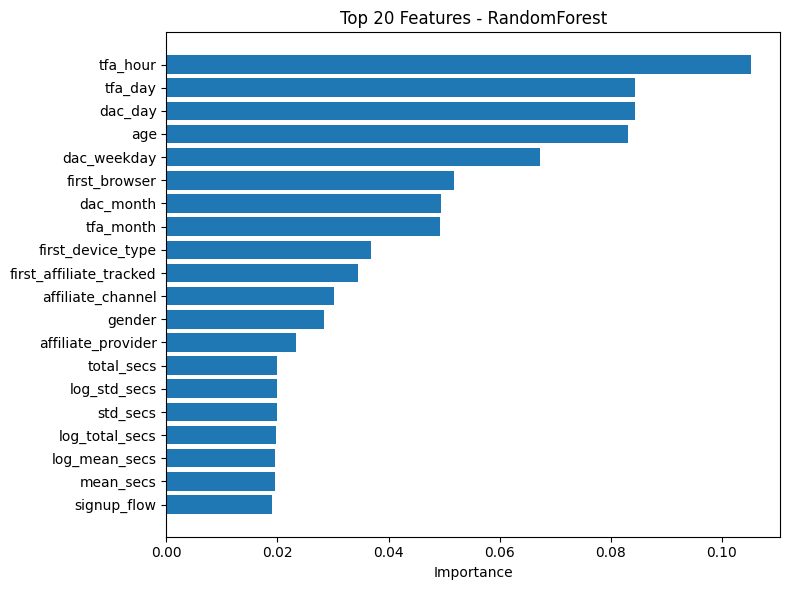

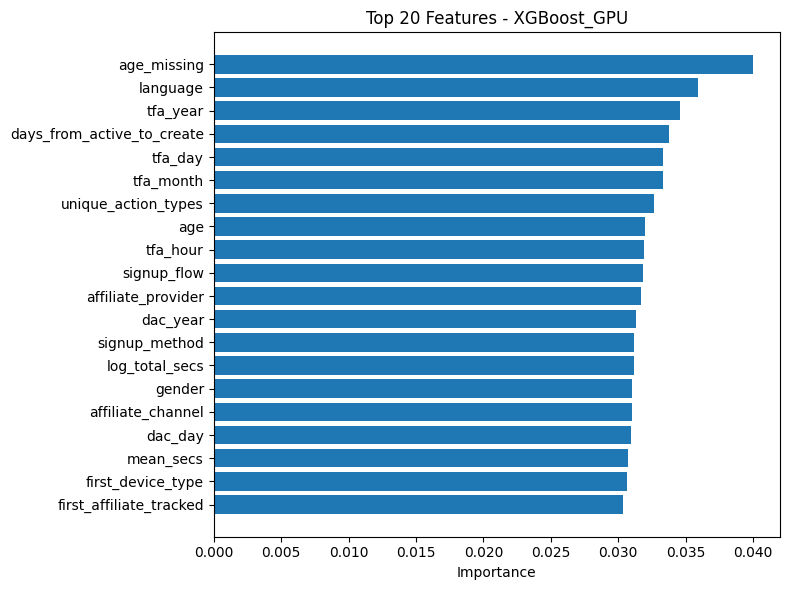

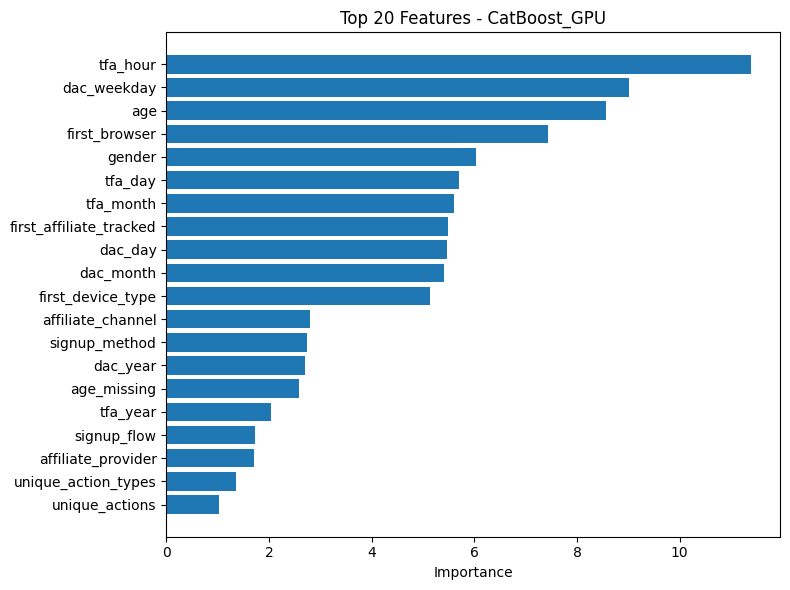

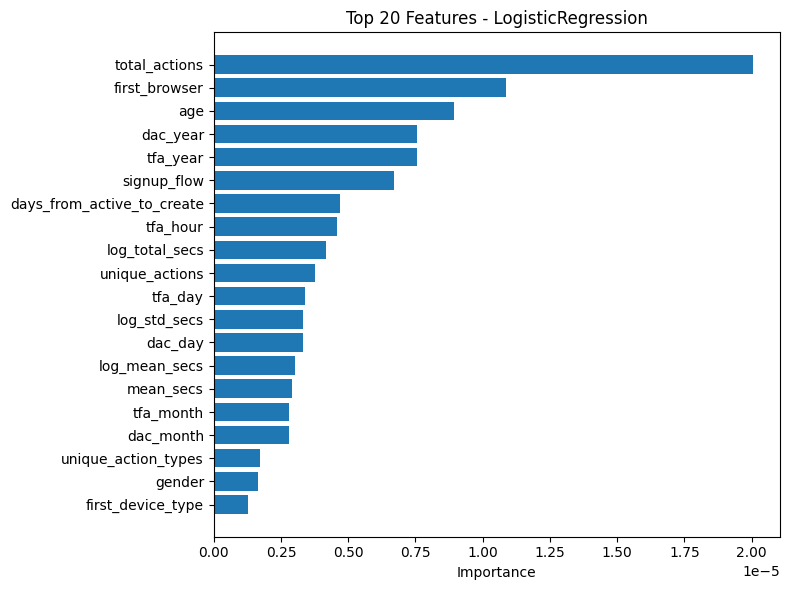

In [87]:
import matplotlib.pyplot as plt

def plot_top_features(importance_series, model_name, top_n=20):
    top_features = importance_series.head(top_n)[::-1]  # reverse for horizontal bar

    plt.figure(figsize=(8, 6))
    plt.barh(top_features.index, top_features.values)
    plt.title(f"Top {top_n} Features - {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


for model_name, importance_series in feature_importances.items():
    plot_top_features(importance_series, model_name, top_n=20)


In [88]:
# Select only the 3 good models
models_to_average = ["RandomForest", "XGBoost_GPU", "CatBoost_GPU"]

# Normalize each model importance to sum = 1
normalized_importances = {}

for model_name in models_to_average:
    imp = feature_importances[model_name]
    normalized_importances[model_name] = imp / imp.sum()

# Combine into dataframe
importance_df = pd.DataFrame(normalized_importances)

# Compute average importance
importance_df["AverageImportance"] = importance_df.mean(axis=1)

# Sort descending
avg_importance = importance_df["AverageImportance"].sort_values(ascending=False)

print("Top 20 averaged important features:")
print(avg_importance.head(20))


Top 20 averaged important features:
tfa_hour                   0.083671
age                        0.066879
dac_weekday                0.062305
tfa_day                    0.058238
dac_day                    0.056657
first_browser              0.051948
tfa_month                  0.046232
dac_month                  0.044557
gender                     0.039925
first_affiliate_tracked    0.039900
first_device_type          0.039597
affiliate_channel          0.029707
dac_year                   0.024924
age_missing                0.024701
signup_method              0.024380
affiliate_provider         0.024076
tfa_year                   0.023669
signup_flow                0.022731
mean_secs                  0.020032
std_secs                   0.019328
Name: AverageImportance, dtype: float64


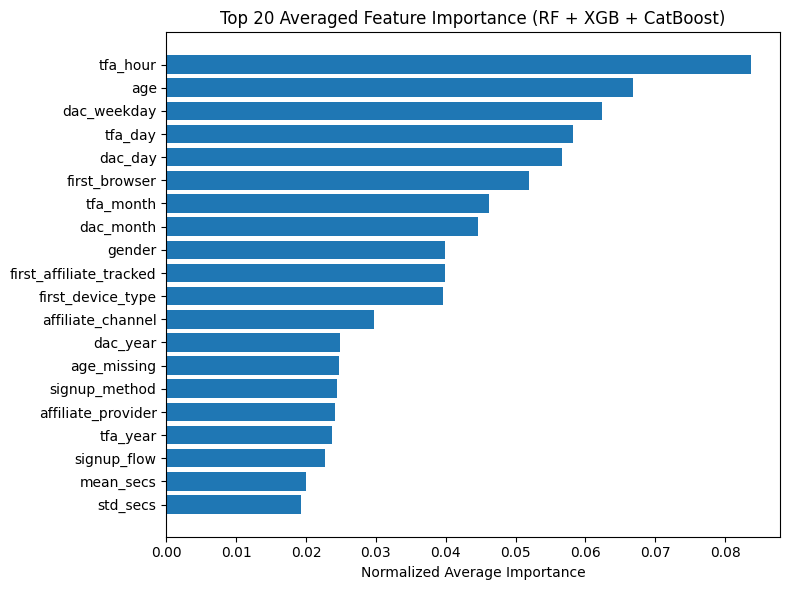

In [89]:
import matplotlib.pyplot as plt

top_n = 20
top_features = avg_importance.head(top_n)[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_features.index, top_features.values)
plt.title("Top 20 Averaged Feature Importance (RF + XGB + CatBoost)")
plt.xlabel("Normalized Average Importance")
plt.tight_layout()
plt.show()


2-stage Modelling

In [104]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# -------------------------
# Choose dataset
# -------------------------
DATASET_TO_USE = "moreData"  # change if needed

if DATASET_TO_USE == "data":
    dataset = data.copy()
elif DATASET_TO_USE == "moreData":
    dataset = moreData.copy()
else:
    raise ValueError("DATASET_TO_USE must be 'data' or 'moreData'")

print("Using dataset:", DATASET_TO_USE)
print("Shape:", dataset.shape)


Using dataset: moreData
Shape: (213451, 40)


In [111]:
# Binary target: 1 = NDF, 0 = Non-NDF
y_binary = (y_raw == "NDF").astype(int)

# Stratified split
X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    stratify=y_binary,
    random_state=42
)

print("Binary train shape:", X_train_bin.shape)
print("Binary val shape:", X_val_bin.shape)
print("NDF ratio in train:", y_train_bin.mean())


Binary train shape: (170760, 36)
Binary val shape: (42691, 36)
NDF ratio in train: 0.5834738814710705


In [112]:
from sklearn.ensemble import RandomForestClassifier

rf_bin = RandomForestClassifier(
    n_estimators=400,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf_bin.fit(X_train_bin, y_train_bin)

print("Stage 1 - Random Forest trained.")


Stage 1 - Random Forest trained.


In [113]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_rf_bin = rf_bin.predict(X_val_bin)

print("\n===== Stage 1 - RF (Binary) =====")
print("Accuracy:", accuracy_score(y_val_bin, y_pred_rf_bin))
print("F1:", f1_score(y_val_bin, y_pred_rf_bin))
print("Recall:", recall_score(y_val_bin, y_pred_rf_bin))

results["Stage1_RF"] = {
    "accuracy": float(accuracy_score(y_val_bin, y_pred_rf_bin)),
    "f1": float(f1_score(y_val_bin, y_pred_rf_bin)),
    "recall": float(recall_score(y_val_bin, y_pred_rf_bin)),
}

results



===== Stage 1 - RF (Binary) =====
Accuracy: 0.7043404933124078
F1: 0.7517992684941204
Recall: 0.7674334577863423


{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799},
 'XGBoost_GPU': {'accuracy': 0.5260593567730903,
  'macro_f1': 0.12139005497620751,
  'weighted_f1': 0.5569782792502919,
  'macro_recall': 0.12578664431854492},
 'Stage1_RF': {'accuracy': 0.7043404933124078,
  'f1': 0.7517992684941204,
  'recall': 0.7674334577863423}}

In [114]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

# Handle imbalance
sample_weights_bin = compute_sample_weight(
    class_weight="balanced",
    y=y_train_bin
)

xgb_bin = xgb.XGBClassifier(
    objective="binary:logistic",

    # GPU
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    gpu_id=0,

    # Parameters
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,

    eval_metric="logloss",
    random_state=42
)

xgb_bin.fit(
    X_train_bin,
    y_train_bin,
    sample_weight=sample_weights_bin,
    eval_set=[(X_val_bin, y_val_bin)],
    verbose=100
)

print("Stage 1 - XGBoost GPU trained.")


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:18:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.68349


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:18:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.56358
[200]	validation_0-logloss:0.56147
[300]	validation_0-logloss:0.56157
[400]	validation_0-logloss:0.56176
[500]	validation_0-logloss:0.56260
[600]	validation_0-logloss:0.56357
[700]	validation_0-logloss:0.56439
[799]	validation_0-logloss:0.56525
Stage 1 - XGBoost GPU trained.


In [115]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_xgb_bin = xgb_bin.predict(X_val_bin)

print("\n===== Stage 1 - XGBoost (Binary) =====")
print("Accuracy:", accuracy_score(y_val_bin, y_pred_xgb_bin))
print("F1:", f1_score(y_val_bin, y_pred_xgb_bin))
print("Recall:", recall_score(y_val_bin, y_pred_xgb_bin))

results["Stage1_XGBoost"] = {
    "accuracy": float(accuracy_score(y_val_bin, y_pred_xgb_bin)),
    "f1": float(f1_score(y_val_bin, y_pred_xgb_bin)),
    "recall": float(recall_score(y_val_bin, y_pred_xgb_bin)),
}

results



===== Stage 1 - XGBoost (Binary) =====
Accuracy: 0.710688435501628
F1: 0.7413782272755827
Recall: 0.7107069733831145


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [14:18:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799},
 'XGBoost_GPU': {'accuracy': 0.5260593567730903,
  'macro_f1': 0.12139005497620751,
  'weighted_f1': 0.5569782792502919,
  'macro_recall': 0.12578664431854492},
 'Stage1_RF': {'accuracy': 0.7043404933124078,
  'f1': 0.7517992684941204,
  'recall': 0.7674334577863423},
 'Stage1_XGBoost': {'accuracy': 0.710688435501628,
  'f1': 0.7413782272755827,
  'recall': 0.7107069733831145}}

In [116]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Sample weights for imbalance
sample_weights_bin = compute_sample_weight(class_weight="balanced", y=y_train_bin)

cat_bin = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",          # good for binary imbalance
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    task_type="GPU",
    devices="0",
    random_seed=42,
    verbose=200
)

cat_bin.fit(
    X_train_bin,
    y_train_bin,
    sample_weight=sample_weights_bin,
    eval_set=(X_val_bin, y_val_bin),
    verbose=200
)

print("Stage 1 - CatBoost GPU trained.")


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7536235	best: 0.7536235 (0)	total: 174ms	remaining: 4m 21s
200:	test: 0.7792967	best: 0.7792967 (200)	total: 3.21s	remaining: 20.7s
400:	test: 0.7804286	best: 0.7804286 (400)	total: 6.42s	remaining: 17.6s
600:	test: 0.7808722	best: 0.7808816 (595)	total: 8.76s	remaining: 13.1s
800:	test: 0.7810176	best: 0.7810251 (750)	total: 12.2s	remaining: 10.7s
1000:	test: 0.7808039	best: 0.7810336 (810)	total: 16.1s	remaining: 8.04s
1200:	test: 0.7804847	best: 0.7810336 (810)	total: 19.7s	remaining: 4.9s
1400:	test: 0.7800671	best: 0.7810336 (810)	total: 23.6s	remaining: 1.67s
1499:	test: 0.7798499	best: 0.7810336 (810)	total: 25.4s	remaining: 0us
bestTest = 0.7810336053
bestIteration = 810
Shrink model to first 811 iterations.
Stage 1 - CatBoost GPU trained.


In [117]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_cat_bin = cat_bin.predict(X_val_bin)
y_pred_cat_bin = y_pred_cat_bin.astype(int).flatten()

print("\n===== Stage 1 - CatBoost (Binary) =====")
print("Accuracy:", accuracy_score(y_val_bin, y_pred_cat_bin))
print("F1:", f1_score(y_val_bin, y_pred_cat_bin))
print("Recall:", recall_score(y_val_bin, y_pred_cat_bin))

results["Stage1_CatBoost"] = {
    "accuracy": float(accuracy_score(y_val_bin, y_pred_cat_bin)),
    "f1": float(f1_score(y_val_bin, y_pred_cat_bin)),
    "recall": float(recall_score(y_val_bin, y_pred_cat_bin)),
}

results



===== Stage 1 - CatBoost (Binary) =====
Accuracy: 0.7122812770841629
F1: 0.7422407823222043
Recall: 0.7099843430085512


{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799},
 'XGBoost_GPU': {'accuracy': 0.5260593567730903,
  'macro_f1': 0.12139005497620751,
  'weighted_f1': 0.5569782792502919,
  'macro_recall': 0.12578664431854492},
 'Stage1_RF': {'accuracy': 0.7043404933124078,
  'f1': 0.7517992684941204,
  'recall': 0.7674334577863423},
 'Stage1_XGBoost': {'accuracy': 0.710688435501628,
  'f1': 0.7413782272755827,
  'recall': 0.7107069733831145},
 'Stage1_CatBoost': {'accuracy': 0.7122812770841629,
  'f1': 0.7422407823222043,
  'recall': 0.7099843430085512}}

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Filter to Non-NDF only
mask_non_ndf = (y_raw != "NDF")

X_stage2 = X.loc[mask_non_ndf].copy()
y_stage2_raw = y_raw.loc[mask_non_ndf].astype(str)

print("Stage2 samples:", X_stage2.shape[0])
print("Stage2 classes:", y_stage2_raw.nunique())
print(y_stage2_raw.value_counts().head(10))

# Encode Stage2 target
stage2_target_encoder = LabelEncoder()
y_stage2 = stage2_target_encoder.fit_transform(y_stage2_raw)

# Stratified split (still imbalanced but less than original)
X_train_s2, X_val_s2, y_train_s2, y_val_s2 = train_test_split(
    X_stage2, y_stage2,
    test_size=0.20,
    stratify=y_stage2,
    random_state=42
)

print("Stage2 train:", X_train_s2.shape, "val:", X_val_s2.shape)


Stage2 samples: 88908
Stage2 classes: 11
country_destination
US       62376
other    10094
FR        5023
IT        2835
GB        2324
ES        2249
CA        1428
DE        1061
NL         762
AU         539
Name: count, dtype: int64
Stage2 train: (71126, 36) val: (17782, 36)


In [119]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

def evaluate_stage2(name, model, X_val, y_val, encoder):
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_val, y_pred, average="weighted", zero_division=0)
    rec_macro = recall_score(y_val, y_pred, average="macro", zero_division=0)

    print(f"\n===== Stage 2 - {name} =====")
    print(f"Accuracy:     {acc:.4f}")
    print(f"Macro F1:     {f1_macro:.4f}")
    print(f"Weighted F1:  {f1_weighted:.4f}")
    print(f"Macro Recall: {rec_macro:.4f}")

    print("\nPer-class report:")
    print(classification_report(
        y_val, y_pred,
        target_names=encoder.classes_,
        zero_division=0
    ))

    return acc, f1_macro, f1_weighted, rec_macro


In [120]:
from sklearn.ensemble import RandomForestClassifier

rf_s2 = RandomForestClassifier(
    n_estimators=600,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf_s2.fit(X_train_s2, y_train_s2)

print("Stage 2 - Random Forest trained.")


Stage 2 - Random Forest trained.


In [121]:
acc, f1m, f1w, rm = evaluate_stage2("RandomForest", rf_s2, X_val_s2, y_val_s2, stage2_target_encoder)

results["Stage2_RF"] = {
    "accuracy": float(acc),
    "macro_f1": float(f1m),
    "weighted_f1": float(f1w),
    "macro_recall": float(rm),
}

results



===== Stage 2 - RandomForest =====
Accuracy:     0.6984
Macro F1:     0.0755
Weighted F1:  0.5781
Macro Recall: 0.0908

Per-class report:
              precision    recall  f1-score   support

          AU       0.00      0.00      0.00       108
          CA       0.00      0.00      0.00       286
          DE       0.00      0.00      0.00       212
          ES       0.00      0.00      0.00       450
          FR       0.05      0.00      0.00      1005
          GB       0.00      0.00      0.00       465
          IT       0.00      0.00      0.00       567
          NL       0.00      0.00      0.00       152
          PT       0.00      0.00      0.00        43
          US       0.70      0.99      0.82     12475
       other       0.14      0.00      0.01      2019

    accuracy                           0.70     17782
   macro avg       0.08      0.09      0.08     17782
weighted avg       0.51      0.70      0.58     17782



{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799},
 'XGBoost_GPU': {'accuracy': 0.5260593567730903,
  'macro_f1': 0.12139005497620751,
  'weighted_f1': 0.5569782792502919,
  'macro_recall': 0.12578664431854492},
 'Stage1_RF': {'accuracy': 0.7043404933124078,
  'f1': 0.7517992684941204,
  'recall': 0.7674334577863423},
 'Stage1_XGBoost': {'accuracy': 0.710688435501628,
  'f1': 0.7413782272755827,
  'recall': 0.7107069733831145},
 'Stage1_CatBoost': {'accuracy': 0.7122812770841629,
  'f1': 0.7422407823222043,
  'recall': 0.7099843430085512},
 'Stage2_

In [122]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

# handle imbalance inside Stage 2
sample_weights_s2 = compute_sample_weight(class_weight="balanced", y=y_train_s2)

xgb_s2 = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train_s2)),

    # GPU
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    gpu_id=0,

    # params (solid starting point)
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1,

    eval_metric="mlogloss",
    random_state=42
)

xgb_s2.fit(
    X_train_s2,
    y_train_s2,
    sample_weight=sample_weights_s2,
    eval_set=[(X_val_s2, y_val_s2)],
    verbose=100
)

print("Stage 2 - XGBoost (GPU) trained.")


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:28:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:28:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:2.39412
[100]	validation_0-mlogloss:2.17094
[200]	validation_0-mlogloss:2.03512
[300]	validation_0-mlogloss:1.92153
[400]	validation_0-mlogloss:1.82698
[500]	validation_0-mlogloss:1.75039
[600]	validation_0-mlogloss:1.68926
[700]	validation_0-mlogloss:1.64009
[800]	validation_0-mlogloss:1.60064
[900]	validation_0-mlogloss:1.56884
[1000]	validation_0-mlogloss:1.54371
[1100]	validation_0-mlogloss:1.52335
[1199]	validation_0-mlogloss:1.50798
Stage 2 - XGBoost (GPU) trained.


In [123]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_xgb_s2 = xgb_s2.predict(X_val_s2)

acc, f1m, f1w, rm = evaluate_stage2("XGBoost_GPU", xgb_s2, X_val_s2, y_val_s2, stage2_target_encoder)

results["Stage2_XGBoost"] = {
    "accuracy": float(acc),
    "macro_f1": float(f1m),
    "weighted_f1": float(f1w),
    "macro_recall": float(rm),
}

results


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [14:30:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:



===== Stage 2 - XGBoost_GPU =====
Accuracy:     0.5029
Macro F1:     0.1018
Weighted F1:  0.5162
Macro Recall: 0.1037

Per-class report:
              precision    recall  f1-score   support

          AU       0.03      0.01      0.01       108
          CA       0.02      0.01      0.01       286
          DE       0.02      0.01      0.01       212
          ES       0.05      0.04      0.05       450
          FR       0.07      0.12      0.09      1005
          GB       0.04      0.04      0.04       465
          IT       0.04      0.04      0.04       567
          NL       0.00      0.00      0.00       152
          PT       0.00      0.00      0.00        43
          US       0.72      0.67      0.70     12475
       other       0.14      0.20      0.17      2019

    accuracy                           0.50     17782
   macro avg       0.10      0.10      0.10     17782
weighted avg       0.53      0.50      0.52     17782



{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799},
 'XGBoost_GPU': {'accuracy': 0.5260593567730903,
  'macro_f1': 0.12139005497620751,
  'weighted_f1': 0.5569782792502919,
  'macro_recall': 0.12578664431854492},
 'Stage1_RF': {'accuracy': 0.7043404933124078,
  'f1': 0.7517992684941204,
  'recall': 0.7674334577863423},
 'Stage1_XGBoost': {'accuracy': 0.710688435501628,
  'f1': 0.7413782272755827,
  'recall': 0.7107069733831145},
 'Stage1_CatBoost': {'accuracy': 0.7122812770841629,
  'f1': 0.7422407823222043,
  'recall': 0.7099843430085512},
 'Stage2_

In [124]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

# sample weights for imbalance within stage 2
sample_weights_s2 = compute_sample_weight(class_weight="balanced", y=y_train_s2)

cat_s2 = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    task_type="GPU",
    devices="0",
    random_seed=42,
    verbose=200
)

cat_s2.fit(
    X_train_s2,
    y_train_s2,
    sample_weight=sample_weights_s2,
    eval_set=(X_val_s2, y_val_s2),
    verbose=200
)

print("Stage 2 - CatBoost (GPU) trained.")


0:	learn: 2.3911050	test: 2.3968242	best: 2.3968242 (0)	total: 138ms	remaining: 4m 35s
200:	learn: 1.7513491	test: 2.2541501	best: 2.2541501 (200)	total: 5.98s	remaining: 53.6s
400:	learn: 1.4642253	test: 2.1657626	best: 2.1657626 (400)	total: 11.3s	remaining: 44.9s
600:	learn: 1.2574609	test: 2.0935505	best: 2.0935505 (600)	total: 17.2s	remaining: 39.9s
800:	learn: 1.1045114	test: 2.0345117	best: 2.0345117 (800)	total: 22.5s	remaining: 33.7s
1000:	learn: 0.9896828	test: 1.9855678	best: 1.9855678 (1000)	total: 27.5s	remaining: 27.5s
1200:	learn: 0.8955091	test: 1.9434903	best: 1.9434903 (1200)	total: 32.8s	remaining: 21.8s
1400:	learn: 0.8139009	test: 1.9053632	best: 1.9053632 (1400)	total: 37.7s	remaining: 16.1s
1600:	learn: 0.7402905	test: 1.8681143	best: 1.8681143 (1600)	total: 42.4s	remaining: 10.6s
1800:	learn: 0.6808680	test: 1.8363006	best: 1.8363006 (1800)	total: 47.8s	remaining: 5.28s
1999:	learn: 0.6295981	test: 1.8080357	best: 1.8080357 (1999)	total: 52.9s	remaining: 0us
bes

In [125]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_cat_s2 = cat_s2.predict(X_val_s2)
y_pred_cat_s2 = y_pred_cat_s2.flatten().astype(int)

acc, f1m, f1w, rm = evaluate_stage2("CatBoost_GPU", cat_s2, X_val_s2, y_val_s2, stage2_target_encoder)

results["Stage2_CatBoost"] = {
    "accuracy": float(acc),
    "macro_f1": float(f1m),
    "weighted_f1": float(f1w),
    "macro_recall": float(rm),
}

results



===== Stage 2 - CatBoost_GPU =====
Accuracy:     0.3090
Macro F1:     0.0914
Weighted F1:  0.3826
Macro Recall: 0.1081

Per-class report:
              precision    recall  f1-score   support

          AU       0.01      0.02      0.01       108
          CA       0.02      0.05      0.02       286
          DE       0.02      0.07      0.03       212
          ES       0.03      0.08      0.04       450
          FR       0.07      0.17      0.10      1005
          GB       0.03      0.08      0.04       465
          IT       0.04      0.11      0.06       567
          NL       0.01      0.01      0.01       152
          PT       0.00      0.00      0.00        43
          US       0.75      0.38      0.50     12475
       other       0.15      0.24      0.18      2019

    accuracy                           0.31     17782
   macro avg       0.10      0.11      0.09     17782
weighted avg       0.55      0.31      0.38     17782



{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799},
 'XGBoost_GPU': {'accuracy': 0.5260593567730903,
  'macro_f1': 0.12139005497620751,
  'weighted_f1': 0.5569782792502919,
  'macro_recall': 0.12578664431854492},
 'Stage1_RF': {'accuracy': 0.7043404933124078,
  'f1': 0.7517992684941204,
  'recall': 0.7674334577863423},
 'Stage1_XGBoost': {'accuracy': 0.710688435501628,
  'f1': 0.7413782272755827,
  'recall': 0.7107069733831145},
 'Stage1_CatBoost': {'accuracy': 0.7122812770841629,
  'f1': 0.7422407823222043,
  'recall': 0.7099843430085512},
 'Stage2_

In [128]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# y_raw already exists from your earlier code (country_destination as strings)
# X already exists (features encoded, list cols dropped)

# Encode full multiclass target ONCE
target_encoder_full = LabelEncoder()
y_full = target_encoder_full.fit_transform(y_raw)

# One global split (this is the ONLY split we use)
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=42
)

# Convert y back to strings for creating Stage1/Stage2 labels consistently
y_train_str = target_encoder_full.inverse_transform(y_train_full)
y_val_str   = target_encoder_full.inverse_transform(y_val_full)

# Stage 1 binary labels (1 = NDF, 0 = Non-NDF)
y_train_bin = (y_train_str == "NDF").astype(int)
y_val_bin   = (y_val_str == "NDF").astype(int)

print("Global split shapes:", X_train_full.shape, X_val_full.shape)
print("Train NDF ratio:", y_train_bin.mean(), "Val NDF ratio:", y_val_bin.mean())


Global split shapes: (170760, 36) (42691, 36)
Train NDF ratio: 0.5834738814710705 Val NDF ratio: 0.5834719261671079


In [129]:
# Stage 2 is trained/evaluated ONLY on Non-NDF rows
train_non_ndf_idx = np.where(y_train_bin == 0)[0]
val_non_ndf_idx   = np.where(y_val_bin == 0)[0]

X_train_s2 = X_train_full.iloc[train_non_ndf_idx].copy()
X_val_s2   = X_val_full.iloc[val_non_ndf_idx].copy()

y_train_s2_str = y_train_str[train_non_ndf_idx]
y_val_s2_str   = y_val_str[val_non_ndf_idx]

# Stage2 encoder (no NDF)
stage2_encoder = LabelEncoder()
y_train_s2 = stage2_encoder.fit_transform(y_train_s2_str)
y_val_s2   = stage2_encoder.transform(y_val_s2_str)

print("Stage2 train:", X_train_s2.shape, "Stage2 val:", X_val_s2.shape)
print("Stage2 classes:", list(stage2_encoder.classes_))


Stage2 train: (71126, 36) Stage2 val: (17782, 36)
Stage2 classes: ['AU', 'CA', 'DE', 'ES', 'FR', 'GB', 'IT', 'NL', 'PT', 'US', 'other']


In [130]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

w1 = compute_sample_weight(class_weight="balanced", y=y_train_bin)

stage1 = xgb.XGBClassifier(
    objective="binary:logistic",
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    gpu_id=0,
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42
)

stage1.fit(
    X_train_full, y_train_bin,
    sample_weight=w1,
    eval_set=[(X_val_full, y_val_bin)],
    verbose=100
)

print("Stage 1 trained.")


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:05:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.68348


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:05:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.56470
[200]	validation_0-logloss:0.56257
[300]	validation_0-logloss:0.56240
[400]	validation_0-logloss:0.56274
[500]	validation_0-logloss:0.56325
[600]	validation_0-logloss:0.56369
[700]	validation_0-logloss:0.56451
[799]	validation_0-logloss:0.56527
Stage 1 trained.


In [131]:
w2 = compute_sample_weight(class_weight="balanced", y=y_train_s2)

stage2 = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train_s2)),
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    gpu_id=0,
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    random_state=42
)

stage2.fit(
    X_train_s2, y_train_s2,
    sample_weight=w2,
    eval_set=[(X_val_s2, y_val_s2)],
    verbose=100
)

print("Stage 2 trained.")


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:05:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:05:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:2.39388
[100]	validation_0-mlogloss:2.16339
[200]	validation_0-mlogloss:2.02938
[300]	validation_0-mlogloss:1.91708
[400]	validation_0-mlogloss:1.82478
[500]	validation_0-mlogloss:1.74926
[600]	validation_0-mlogloss:1.69130
[700]	validation_0-mlogloss:1.64163
[800]	validation_0-mlogloss:1.60188
[900]	validation_0-mlogloss:1.57023
[1000]	validation_0-mlogloss:1.54510
[1100]	validation_0-mlogloss:1.52516
[1199]	validation_0-mlogloss:1.51005
Stage 2 trained.


In [132]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

# Stage1: predict NDF vs non-NDF on ALL validation rows
pred_is_ndf = stage1.predict(X_val_full).astype(int)  # 1 => NDF

final_pred = np.array(["NDF"] * len(X_val_full), dtype=object)

# For predicted non-NDF, run stage2
idx_pred_non_ndf = np.where(pred_is_ndf == 0)[0]
if len(idx_pred_non_ndf) > 0:
    pred_s2 = stage2.predict(X_val_full.iloc[idx_pred_non_ndf])
    final_pred[idx_pred_non_ndf] = stage2_encoder.inverse_transform(pred_s2.astype(int))

# True labels are y_val_str (aligned!)
y_true = y_val_str

print("===== Proper 2-Stage (Aligned) =====")
print("Accuracy:", accuracy_score(y_true, final_pred))
print("Macro F1:", f1_score(y_true, final_pred, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_true, final_pred, average="weighted", zero_division=0))
print("Macro Recall:", recall_score(y_true, final_pred, average="macro", zero_division=0))

print("\nReport:")
print(classification_report(y_true, final_pred, zero_division=0))


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [15:07:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [15:07:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


===== Proper 2-Stage (Aligned) =====
Accuracy: 0.5652713686725539
Macro F1: 0.1227847105086256
Weighted F1: 0.5782705988820179
Macro Recall: 0.12524871885733221

Report:
              precision    recall  f1-score   support

          AU       0.00      0.00      0.00       108
          CA       0.01      0.01      0.01       286
          DE       0.00      0.00      0.00       212
          ES       0.02      0.03      0.03       450
          FR       0.05      0.08      0.06      1005
          GB       0.03      0.03      0.03       465
          IT       0.03      0.03      0.03       567
         NDF       0.77      0.71      0.74     24909
          NL       0.00      0.00      0.00       152
          PT       0.00      0.00      0.00        43
          US       0.47      0.49      0.48     12475
       other       0.09      0.13      0.10      2019

    accuracy                           0.57     42691
   macro avg       0.12      0.13      0.12     42691
weighted avg      

In [135]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

results["TwoStage_XGB_XGB"] = {
    "accuracy": float(accuracy_score(y_true, final_pred)),
    "macro_f1": float(f1_score(y_true, final_pred, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(y_true, final_pred, average="weighted", zero_division=0)),
    "macro_recall": float(recall_score(y_true, final_pred, average="macro", zero_division=0)),
}

results


{'LogisticRegression': {'accuracy': 0.058185566044365325,
  'macro_f1': 0.019151062481216025,
  'weighted_f1': 0.0944470456816442,
  'macro_recall': 0.09373715226501439},
 'RandomForest': {'accuracy': 0.6206694619474831,
  'macro_f1': 0.10029062163635055,
  'weighted_f1': 0.5684019820850196,
  'macro_recall': 0.10589083459500459},
 'CatBoost_GPU': {'accuracy': 0.41172612494436767,
  'macro_f1': 0.10790315945752223,
  'weighted_f1': 0.48613161437405245,
  'macro_recall': 0.1293999085723799},
 'XGBoost_GPU': {'accuracy': 0.5260593567730903,
  'macro_f1': 0.12139005497620751,
  'weighted_f1': 0.5569782792502919,
  'macro_recall': 0.12578664431854492},
 'Stage1_RF': {'accuracy': 0.7043404933124078,
  'f1': 0.7517992684941204,
  'recall': 0.7674334577863423},
 'Stage1_XGBoost': {'accuracy': 0.710688435501628,
  'f1': 0.7413782272755827,
  'recall': 0.7107069733831145},
 'Stage1_CatBoost': {'accuracy': 0.7122812770841629,
  'f1': 0.7422407823222043,
  'recall': 0.7099843430085512},
 'Stage2_

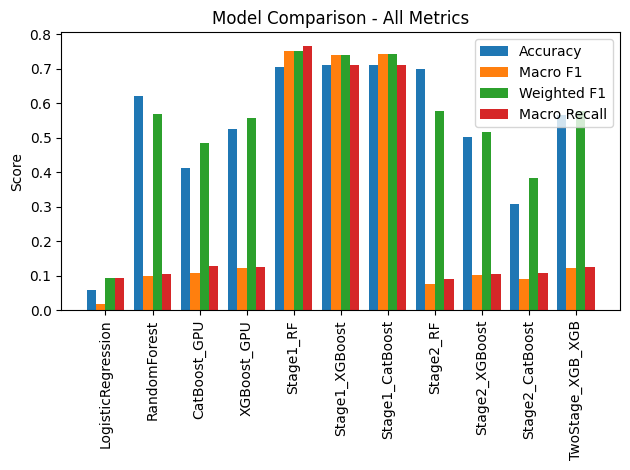

In [136]:
import matplotlib.pyplot as plt
import numpy as np

models = list(results.keys())

accuracy = [results[m]["accuracy"] for m in models]
macro_f1 = [results[m].get("macro_f1", results[m].get("f1")) for m in models]
weighted_f1 = [results[m].get("weighted_f1", results[m].get("f1")) for m in models]
macro_recall = [results[m].get("macro_recall", results[m].get("recall")) for m in models]

x = np.arange(len(models))
width = 0.2

plt.figure()

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, macro_f1, width, label="Macro F1")
plt.bar(x + 0.5*width, weighted_f1, width, label="Weighted F1")
plt.bar(x + 1.5*width, macro_recall, width, label="Macro Recall")

plt.xticks(x, models, rotation=90)
plt.ylabel("Score")
plt.title("Model Comparison - All Metrics")
plt.legend()

plt.tight_layout()
plt.show()


1️⃣ Stronger class weighting / Focal loss
Increase penalty for rare countries so model focuses on minority classes.

2️⃣ Resampling (SMOTE / undersampling)
Oversample rare classes or reduce NDF/US in training.

3️⃣ Better behavioral features
Add top action_type counts, ratios, entropy, device dominance.

4️⃣ Threshold tuning / probability calibration
Use class-specific thresholds instead of default 0.5.


1.Random baseline (sanity check)

2.Most-frequent baseline (always predict top 5 global destinations: NDF, US, other, FR, IT)

3.Single-stage Random Forest → take predict_proba, return top-5 classes

4.Single-stage XGBoost (GPU) → predict_proba top-5 (usually big jump)

5.Single-stage CatBoost (GPU) → predict_proba top-5 (often comparable/better)

6.Two-stage top-5 (best Stage1 + best Stage2)

Stage1 gives P(NDF)

Stage2 gives probabilities over non-NDF classes

Combine into one full probability vector → take top-5

7.Probability calibration + thresholding (calibrate probs, improves ranking/top-5)

8.Ensemble / stacking (average probs of XGB + CatBoost + two-stage) → top-5

In [148]:
import numpy as np

def top5_accuracy(y_true_idx, top5_pred_idx):
    # y_true_idx: shape (n,)
    # top5_pred_idx: shape (n, 5)
    return float(np.mean([y_true_idx[i] in top5_pred_idx[i] for i in range(len(y_true_idx))]))

def mapk(y_true_idx, topk_pred_idx, k=5):
    # Mean Average Precision at k (MAP@k)
    # For single-label classification: AP = 1/rank if true label appears in top-k else 0
    ap = 0.0
    for i in range(len(y_true_idx)):
        true = y_true_idx[i]
        preds = list(topk_pred_idx[i])[:k]
        if true in preds:
            rank = preds.index(true) + 1
            ap += 1.0 / rank
    return float(ap / len(y_true_idx))


In [149]:
y_val_full_idx = y_val_full  # already encoded ints
class_names = target_encoder_full.classes_
num_classes = len(class_names)

print("Val size:", len(y_val_full_idx), "Num classes:", num_classes)


Val size: 42691 Num classes: 12


In [150]:
# Find top-5 most common classes in TRAIN (not full dataset) to avoid leakage
train_counts = np.bincount(y_train_full, minlength=num_classes)
top5_global = np.argsort(train_counts)[::-1][:5]

print("Global top-5 destinations:", list(class_names[top5_global]))

# Predict same top-5 for every validation row
top5_pred_global = np.tile(top5_global, (len(y_val_full_idx), 1))

acc5 = top5_accuracy(y_val_full_idx, top5_pred_global)
map5 = mapk(y_val_full_idx, top5_pred_global, k=5)

print("===== Baseline: Global Top-5 =====")
print("Top-5 Accuracy:", acc5)
print("MAP@5:", map5)


Global top-5 destinations: ['NDF', 'US', 'other', 'FR', 'IT']
===== Baseline: Global Top-5 =====
Top-5 Accuracy: 0.9598041741819119
MAP@5: 0.7538860649785518


In [151]:
rng = np.random.default_rng(42)

top5_pred_random = np.vstack([
    rng.choice(num_classes, size=5, replace=False)
    for _ in range(len(y_val_full_idx))
])

acc5_rand = top5_accuracy(y_val_full_idx, top5_pred_random)
map5_rand = mapk(y_val_full_idx, top5_pred_random, k=5)

print("===== Baseline: Random Top-5 =====")
print("Top-5 Accuracy:", acc5_rand)
print("MAP@5:", map5_rand)


===== Baseline: Random Top-5 =====
Top-5 Accuracy: 0.4171371014968026
MAP@5: 0.18926471621651123


In [152]:
from sklearn.ensemble import RandomForestClassifier

rf_top5 = RandomForestClassifier(
    n_estimators=700,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf_top5.fit(X_train_full, y_train_full)

print("Random Forest trained for Top-5.")


Random Forest trained for Top-5.


In [153]:
import numpy as np

proba_rf = rf_top5.predict_proba(X_val_full)  # shape (n, num_classes)

# Top-5 indices by probability (descending)
top5_rf = np.argsort(proba_rf, axis=1)[:, ::-1][:, :5]

acc5_rf = top5_accuracy(y_val_full, top5_rf)
map5_rf = mapk(y_val_full, top5_rf, k=5)

print("===== Random Forest Top-5 =====")
print("Top-5 Accuracy:", acc5_rf)
print("MAP@5:", map5_rf)


===== Random Forest Top-5 =====
Top-5 Accuracy: 0.9531985664425757
MAP@5: 0.7717364315663593


In [162]:
top5_results = {}

# Baselines (from earlier cells)
top5_results["Baseline_GlobalTop5"] = {"top5_accuracy": float(acc5), "map5": float(map5)}
top5_results["Baseline_RandomTop5"] = {"top5_accuracy": float(acc5_rand), "map5": float(map5_rand)}

# Random Forest
top5_results["RandomForest"] = {"top5_accuracy": float(acc5_rf), "map5": float(map5_rf)}

top5_results


{'Baseline_GlobalTop5': {'top5_accuracy': 0.9598041741819119,
  'map5': 0.7538860649785518},
 'Baseline_RandomTop5': {'top5_accuracy': 0.4171371014968026,
  'map5': 0.18926471621651123},
 'RandomForest': {'top5_accuracy': 0.9531985664425757,
  'map5': 0.7717364315663593}}

In [163]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

w_full = compute_sample_weight(class_weight="balanced", y=y_train_full)

xgb_top5 = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train_full)),

    # GPU (new API)
    tree_method="hist",
    device="cuda",

    n_estimators=1500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1,

    eval_metric="mlogloss",
    random_state=42
)

xgb_top5.fit(
    X_train_full, y_train_full,
    sample_weight=w_full,
    eval_set=[(X_val_full, y_val_full)],
    verbose=100
)

print("XGBoost (GPU) trained for Top-5.")


[0]	validation_0-mlogloss:2.46275
[100]	validation_0-mlogloss:2.01125
[200]	validation_0-mlogloss:1.87637
[300]	validation_0-mlogloss:1.77410
[400]	validation_0-mlogloss:1.68574
[500]	validation_0-mlogloss:1.61155
[600]	validation_0-mlogloss:1.55088
[700]	validation_0-mlogloss:1.49888
[800]	validation_0-mlogloss:1.45587
[900]	validation_0-mlogloss:1.41985
[1000]	validation_0-mlogloss:1.39073
[1100]	validation_0-mlogloss:1.36512
[1200]	validation_0-mlogloss:1.34521
[1300]	validation_0-mlogloss:1.32846
[1400]	validation_0-mlogloss:1.31430
[1499]	validation_0-mlogloss:1.30343
XGBoost (GPU) trained for Top-5.


In [164]:
proba_xgb = xgb_top5.predict_proba(X_val_full)
top5_xgb = np.argsort(proba_xgb, axis=1)[:, ::-1][:, :5]

acc5_xgb = top5_accuracy(y_val_full, top5_xgb)
map5_xgb = mapk(y_val_full, top5_xgb, k=5)

print("===== XGBoost (GPU) Top-5 =====")
print("Top-5 Accuracy:", acc5_xgb)
print("MAP@5:", map5_xgb)

top5_results["XGBoost_GPU"] = {"top5_accuracy": float(acc5_xgb), "map5": float(map5_xgb)}
top5_results


===== XGBoost (GPU) Top-5 =====
Top-5 Accuracy: 0.9524255697922279
MAP@5: 0.7165905382086449


{'Baseline_GlobalTop5': {'top5_accuracy': 0.9598041741819119,
  'map5': 0.7538860649785518},
 'Baseline_RandomTop5': {'top5_accuracy': 0.4171371014968026,
  'map5': 0.18926471621651123},
 'RandomForest': {'top5_accuracy': 0.9531985664425757,
  'map5': 0.7717364315663593},
 'XGBoost_GPU': {'top5_accuracy': 0.9524255697922279,
  'map5': 0.7165905382086449}}